# Speech Information Processing
## Week 6 Exercise: Comparing ASR Models

In this notebook, we analyze modern ASR systems.

We focus on:

• CTC-based ASR (wav2vec + CTC decoding)  
• Attention-based models  

---

## Tasks

1. Run CTC-based ASR  
2. Understand attention behavior  
3. Analyze latency vs accuracy  
4. Final analysis  

---

## Goal

• connect theory with real systems  
• understand model behavior  

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import os

print("Current directory:", os.getcwd())
print("Files in directory:", os.listdir())

Current directory: /Users/tmatsui/Dropbox/SLAI/SIP/notebooks
Files in directory: ['window_resolution_example.png', 'SIP_Week2_Data_Download.ipynb', 'tts_sample.mp3', '.DS_Store', 'mfcc_chirp.png', 'week5_outputs', 'SIP_generate_audio_samples.ipynb', 'SIP_Week2_LogMel_MFCC_Visualization.ipynb', 'week1_frame_variance.png', 'audio_samples', 'SIP_Week6_Template.ipynb', '__MACOSX', 'test_16k.wav', 'SIP_Week1_Template.ipynb', 'model.zip', 'tts_sample.wav', 'audio_samples.zip', 'model', 'mfcc_speech_without_c0.png', '.ipynb_checkpoints', 'SIP_Week3_Synthetic_Data_Generation.ipynb', 'SIP_Week5_Template.ipynb', 'week1_frame_stats.csv', 'test.wav', 'SIP_Week2_Template.ipynb', 'data', 'SIP_Week3_Template.ipynb', 'SIP_Week4_Template.ipynb']


In [3]:
import os

data_path = "../data"

print("Data path:", data_path)
print("Exists:", os.path.exists(data_path))

if os.path.exists(data_path):
    print("Files:", os.listdir(data_path))
else:
    print("ERROR: data folder not found")

Data path: ../data
Exists: True
Files: ['.DS_Store', 'test-clean.tar.gz', 'LibriSpeech', 'audio_samples', 'waves_yesno.tar.gz', 'sample.m4a', 'waves_yesno', 'sample.wav']


## Task 1: Run CTC-based ASR

In this task, we run a real speech recognition system.

We use:

• wav2vec 2.0 as the encoder  
• CTC decoding to produce text  

---

Pipeline:

audio → wav2vec → emissions → CTC decoding → text  

---

Goal:

• understand how ASR systems convert audio into text  

### Step 0: Load Pretrained ASR Model

We load a pretrained speech recognition model.

This model consists of:

- wav2vec 2.0 as the encoder (extracts speech representations)
- a CTC-based output layer (converts probabilities into text)

---

What this step does:

- loads the model into memory
- prepares it for speech recognition

---

Note:

- the model is already trained
- we will only run inference (no training)

In [4]:
!pip install torchaudio --quiet

In [5]:
import torch
import torchaudio

bundle = torchaudio.pipelines.WAV2VEC2_ASR_BASE_960H
model = bundle.get_model()

print("Model loaded successfully")

Model loaded successfully


### Step 1: Download Synthetic Speech Samples

We download a zip file containing synthetic speech samples.

The files will be extracted in the current directory.

In [6]:
import os
import urllib.request
import zipfile
import glob

zip_url = "https://github.com/matsui-tomoko/speech-information-processing/raw/main/data/audio_samples.zip"
zip_path = "audio_samples.zip"

print("Downloading audio samples...")

urllib.request.urlretrieve(zip_url, zip_path)

print("Download complete")

# unzip in current directory
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(".")

print("Extraction complete")

# list files
audio_paths = sorted(glob.glob("audio_samples/synthetic_speech/sample_*.wav"))

print("Number of audio files:", len(audio_paths))
print("First 3 files:", audio_paths[:3])

Download complete
Extraction complete
Number of audio files: 10
First 3 files: ['audio_samples/synthetic_speech/sample_0.wav', 'audio_samples/synthetic_speech/sample_1.wav', 'audio_samples/synthetic_speech/sample_2.wav']


### Step 2: Load One Example Audio

Let us inspect one audio sample.

In [7]:
import torchaudio

waveform, sample_rate = torchaudio.load(audio_paths[0])

print("Example file:", audio_paths[0])
print("Waveform shape:", waveform.shape)
print("Sample rate:", sample_rate)

Example file: audio_samples/synthetic_speech/sample_0.wav
Waveform shape: torch.Size([1, 65280])
Sample rate: 16000


### Step 3: Listen to One Example Audio

Let us listen to the audio.

In [8]:
from IPython.display import Audio

Audio(audio_paths[0])

### Step 4: Generate CTC Outputs for All Audio Files

We now run the pretrained wav2vec 2.0 model on all synthetic speech samples.

This produces CTC-based transcriptions for comparison.

In [9]:
ctc_outputs = []

for path in audio_paths:
    waveform, sample_rate = torchaudio.load(path)

    with torch.inference_mode():
        emissions, _ = model(waveform)

    labels = bundle.get_labels()

    # Step 1: pick the most likely character at each time step
    indices = torch.argmax(emissions, dim=-1)[0]

    # Step 2: convert indices to tokens
    tokens = [labels[i] for i in indices]

    # Step 3: remove consecutive duplicates
    dedup = []
    for t in tokens:
        if len(dedup) == 0 or t != dedup[-1]:
            dedup.append(t)

    # Step 4: remove blank symbol and replace word boundary
    blank_token = labels[0]
    transcript = "".join([t for t in dedup if t != blank_token])
    transcript = transcript.replace("|", " ")

    ctc_outputs.append(transcript)

print("Number of CTC outputs:", len(ctc_outputs))
print("First 3 outputs:")
for x in ctc_outputs[:3]:
    print("-", x)

Number of CTC outputs: 10
First 3 outputs:
- HELLO THIS IS A TEST SENTENCE FOR OUR DATA SET 
- WE ARE GENERATING SYNTHETIC SPEECH FOR THE ROBUSTNESS EXPERIMENT 
- THIS RECORDING WILL HELP EVALUATE THE ROBUSTNESS OF OUR ORDIO FEATURES 


### Step 5: Define Ground-Truth Sentences

These are the correct sentences corresponding to the 10 synthetic audio samples.

In [10]:
sentences = [
    "Hello, this is a test sentence for our dataset.",
    "We are generating synthetic speech for the robustness experiment.",
    "This recording will help evaluate the robustness of our audio features.",
    "Please speak clearly and naturally while reading these lines.",
    "The quick brown fox jumps over the lazy dog, a classic pangram for testing.",
    "Our experiment requires clean and noisy samples to compare results.",
    "Make sure to enunciate each word so it is easy to understand.",
    "Background noise can affect speech recognition performance.",
    "We will also test how reverberation changes the spectral features.",
    "Thank you for contributing your voice to this research project."
]

print("Number of reference sentences:", len(sentences))
print("First reference sentence:")
print(sentences[0])

Number of reference sentences: 10
First reference sentence:
Hello, this is a test sentence for our dataset.


### Step 6: Compare Reference and CTC Output

Let us compare the correct sentence with the CTC-based transcription.

In [11]:
for i in range(len(sentences)):
    print(f"Example {i}")
    print("Reference:", sentences[i])
    print("CTC output:", ctc_outputs[i])
    print("-" * 60)

Example 0
Reference: Hello, this is a test sentence for our dataset.
CTC output: HELLO THIS IS A TEST SENTENCE FOR OUR DATA SET 
------------------------------------------------------------
Example 1
Reference: We are generating synthetic speech for the robustness experiment.
CTC output: WE ARE GENERATING SYNTHETIC SPEECH FOR THE ROBUSTNESS EXPERIMENT 
------------------------------------------------------------
Example 2
Reference: This recording will help evaluate the robustness of our audio features.
CTC output: THIS RECORDING WILL HELP EVALUATE THE ROBUSTNESS OF OUR ORDIO FEATURES 
------------------------------------------------------------
Example 3
Reference: Please speak clearly and naturally while reading these lines.
CTC output: PLEASE SPEAK CLEARLY AND NATURALLY WHILE READING THESE LINES 
------------------------------------------------------------
Example 4
Reference: The quick brown fox jumps over the lazy dog, a classic pangram for testing.
CTC output: THE QUICK BROWN FOX

### Step 7: Normalize Text

Before evaluation, we normalize the text:

- convert to lowercase
- remove punctuation
- remove extra spaces

This makes the comparison fairer.

In [12]:
import re

def normalize_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)   # remove punctuation
    text = re.sub(r"\s+", " ", text)      # collapse multiple spaces
    text = text.strip()
    return text

ref_norm = [normalize_text(x) for x in sentences]
ctc_norm = [normalize_text(x) for x in ctc_outputs]

for i in range(len(ref_norm)):
    print(f"Example {i}")
    print("Reference:", ref_norm[i])
    print("CTC output:", ctc_norm[i])
    print("-" * 60)

Example 0
Reference: hello this is a test sentence for our dataset
CTC output: hello this is a test sentence for our data set
------------------------------------------------------------
Example 1
Reference: we are generating synthetic speech for the robustness experiment
CTC output: we are generating synthetic speech for the robustness experiment
------------------------------------------------------------
Example 2
Reference: this recording will help evaluate the robustness of our audio features
CTC output: this recording will help evaluate the robustness of our ordio features
------------------------------------------------------------
Example 3
Reference: please speak clearly and naturally while reading these lines
CTC output: please speak clearly and naturally while reading these lines
------------------------------------------------------------
Example 4
Reference: the quick brown fox jumps over the lazy dog a classic pangram for testing
CTC output: the quick brown fox jumps over

### Step 8: Count Exact Matches

Now let us count how many normalized outputs exactly match the reference.

In [13]:
exact_matches = [r == c for r, c in zip(ref_norm, ctc_norm)]

print("Exact matches:", sum(exact_matches), "/", len(exact_matches))
print("Match results:", exact_matches)

Exact matches: 8 / 10
Match results: [False, True, False, True, True, True, True, True, True, True]


### Step 9: Compute Word Error Rate (WER)

We compute Word Error Rate (WER) to measure recognition errors.

WER is defined as:

WER = (substitutions + insertions + deletions) / number of words

This gives a normalized measure of error.

In [14]:
def wer(reference, hypothesis):
    ref_words = reference.split()
    hyp_words = hypothesis.split()

    # create matrix
    dp = [[0] * (len(hyp_words) + 1) for _ in range(len(ref_words) + 1)]

    # initialize
    for i in range(len(ref_words) + 1):
        dp[i][0] = i
    for j in range(len(hyp_words) + 1):
        dp[0][j] = j

    # fill DP table
    for i in range(1, len(ref_words) + 1):
        for j in range(1, len(hyp_words) + 1):
            if ref_words[i-1] == hyp_words[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = min(
                    dp[i-1][j] + 1,    # deletion
                    dp[i][j-1] + 1,    # insertion
                    dp[i-1][j-1] + 1   # substitution
                )

    return dp[-1][-1] / len(ref_words)

### Step 10: Compute WER for All Samples

In [15]:
wers = []

for r, c in zip(ref_norm, ctc_norm):
    score = wer(r, c)
    wers.append(score)

for i, w in enumerate(wers):
    print(f"Example {i}: WER = {w:.2f}")

print("\nAverage WER:", sum(wers) / len(wers))

Example 0: WER = 0.22
Example 1: WER = 0.00
Example 2: WER = 0.09
Example 3: WER = 0.00
Example 4: WER = 0.00
Example 5: WER = 0.00
Example 6: WER = 0.00
Example 7: WER = 0.00
Example 8: WER = 0.00
Example 9: WER = 0.00

Average WER: 0.031313131313131314


### Task 1 Summary

In this task, we ran a real CTC-based ASR system:

- wav2vec 2.0 as the encoder
- CTC decoding to produce text

We compared the model outputs with the reference sentences
and computed Word Error Rate (WER).

This shows how a real CTC-based ASR system performs in practice.

In [16]:
print("Task 1 Summary")
print("------------------------------")
print("Average WER:", round(sum(wers) / len(wers), 4))
print()
print("Interpretation:")
print("- The model performs well on most samples")
print("- Some errors still appear")
print("- CTC-based ASR converts probabilities into text through decoding")

Task 1 Summary
------------------------------
Average WER: 0.0313

Interpretation:
- The model performs well on most samples
- Some errors still appear
- CTC-based ASR converts probabilities into text through decoding


### Questions for Students

1. Which sentences were recognized correctly?
2. What kinds of errors do you observe?
3. Why do we need CTC decoding after the model output?

## Task 2: Understand Attention

### Goal

Understand how attention uses global context.

---

### What to do

- run a pretrained wav2vec model
- extract attention weights
- visualize attention

---

### Key idea

Attention assigns weights to all input positions.

In [17]:
!pip install transformers --quiet

### Note

You may see warnings during installation.

These are not critical errors and can be safely ignored
if the code runs correctly.

### Step 1: Load a wav2vec 2.0 model with attention output

The torchaudio model used in Task 1 does not directly return attention weights.

So here we use a Hugging Face wav2vec 2.0 CTC model,
which can return attention weights.

Note:
If you see warnings about attention implementation,
they can usually be ignored.
For attention visualization, we explicitly set
`attn_implementation="eager"`.

In [18]:
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC

hf_model_name = "facebook/wav2vec2-base-960h"

processor = Wav2Vec2Processor.from_pretrained(hf_model_name)
hf_model = Wav2Vec2ForCTC.from_pretrained(
    hf_model_name,
    attn_implementation="eager"
)

print("Hugging Face wav2vec 2.0 model loaded successfully")
print("Attention implementation:", hf_model.config._attn_implementation)

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Hugging Face wav2vec 2.0 model loaded successfully
Attention implementation: eager


### Step 2: Load One Audio Sample

We use one audio sample as input.

Note:

- the model processes audio (not text)
- attention operates over time steps

In [19]:
import torchaudio

waveform, sample_rate = torchaudio.load(audio_paths[0])

# convert to mono if needed
if waveform.shape[0] > 1:
    waveform = waveform.mean(dim=0, keepdim=True)

speech = waveform.squeeze().numpy()

print("Waveform shape:", waveform.shape)
print("Sample rate:", sample_rate)

Waveform shape: torch.Size([1, 65280])
Sample rate: 16000


### Step 3: Run Model and Extract Attention

We run the model and extract attention weights.

In [20]:
inputs = processor(
    speech,
    sampling_rate=sample_rate,
    return_tensors="pt",
    padding=True
)

with torch.inference_mode():
    outputs = hf_model(**inputs, output_attentions=True)

logits = outputs.logits
attentions = outputs.attentions

print("Number of layers:", len(attentions))
print("Attention shape:", attentions[0].shape)

Number of layers: 12
Attention shape: torch.Size([1, 12, 203, 203])


### Step 3b: Decode Output (CTC)

We convert the model output into text using the built-in decoder.

This handles blank symbols and duplicates correctly.

In [21]:
pred_ids = torch.argmax(logits, dim=-1)

transcript = processor.batch_decode(pred_ids)[0]

print("Transcription:", transcript)

Transcription: HELLO THIS IS A TEST SENTENCE FOR OUR DATA SET


### Step 4: Visualize Attention

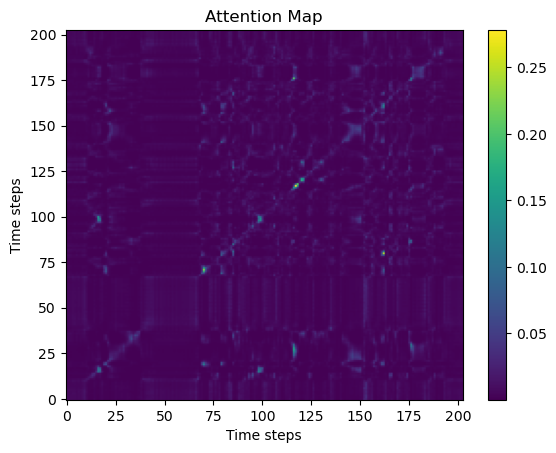

In [22]:
import matplotlib.pyplot as plt

layer_id = 0
head_id = 0

attn_map = attentions[layer_id][0, head_id].cpu().numpy()

plt.imshow(attn_map, aspect="auto", origin="lower")
plt.colorbar()

plt.xlabel("Time steps")
plt.ylabel("Time steps")
plt.title("Attention Map")

plt.show()

### Step 5: Interpret the Attention Map

Now try to answer:

1. Does a word attend mostly to itself?
2. Do nearby words attend strongly to each other?
3. Are there any words that attend more broadly across the sequence?
4. Is attention concentrated near the diagonal, or spread more globally?

### Step 6: Compare Different Attention Heads

Attention is computed using multiple heads.

Each head can focus on different patterns in the input.

We visualize multiple heads to compare their behavior.

In [23]:
layer_id = 0

num_heads = attentions[layer_id].shape[1]
print("Number of heads:", num_heads)

Number of heads: 12


### Visualize Multiple Heads

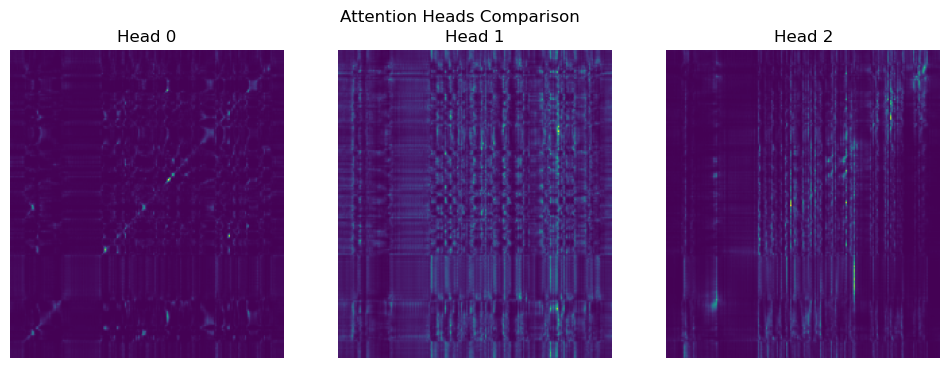

In [24]:
import matplotlib.pyplot as plt

layer_id = 0
heads_to_show = [0, 1, 2]

plt.figure(figsize=(12, 4))

for i, h in enumerate(heads_to_show):
    attn_map = attentions[layer_id][0, h].cpu().numpy()

    plt.subplot(1, len(heads_to_show), i+1)
    plt.imshow(attn_map, aspect="auto", origin="lower")
    plt.title(f"Head {h}")
    plt.axis("off")

plt.suptitle("Attention Heads Comparison")
plt.show()

### How to read attention maps

- vertical axis: query (current time step)
- horizontal axis: key (attended time step)
- color: attention strength

Diagonal patterns indicate local attention.
Vertical patterns indicate broader or global attention.

Different heads show different patterns.

### What Do Attention Heads Learn?

At initialization:

- all heads are random
- they have no predefined roles

During training:

- each head learns different patterns
- roles emerge automatically

---

Important:

- roles are not fixed
- different runs may produce different patterns

---

Observation:

- some heads tend to focus locally
- others may capture long-range relationships

### Why Do Different Heads Behave Differently?

Each attention head uses different learned weights:

- W_Q, W_K, W_V are different for each head

This means:

- each head maps the input into a different feature space
- attention is computed differently in each head

As a result:

- different heads focus on different patterns
- some become local, some global, some specialized

### Task 2 Summary

In this task, we visualized attention weights from a wav2vec 2.0 model.

We observed that:

- attention is computed over time steps in the audio
- different heads show different patterns
- some heads focus locally, others more globally

---

### Key idea

Attention assigns weights to all input positions,
allowing the model to use global context.

In [25]:
print("Task 2 Summary")
print("------------------------------")
print("Attention operates over time steps")
print("Different heads show different patterns")
print("Some heads are more local, others more global")

Task 2 Summary
------------------------------
Attention operates over time steps
Different heads show different patterns
Some heads are more local, others more global


### Questions for Students

1. Do all attention heads behave the same?
2. What patterns do you observe in different heads?
3. Why might multiple attention heads be useful?

### From Attention to Real-Time Systems

So far, we have seen that:

- attention uses global context
- it can look at all time steps

However, in real-time systems:

- we cannot wait for the entire input
- we must process audio with limited context

This leads to an important trade-off:

👉 accuracy vs latency

## Task 3: Latency vs Accuracy

### What is latency?

In real-time systems, the model cannot wait for the full audio.

It must make predictions before seeing future input.

This creates a trade-off:

- more context → better accuracy
- less context → lower latency

### What does "ratio" mean?

The ratio controls how much of the audio is used.

- ratio = 1.0 → full audio
- ratio = 0.5 → first half only
- ratio = 0.3 → first 30%

This simulates limited future context in real-time systems.

### Step 1: Simulate Limited Context

We simulate real-time constraints by truncating the audio.

We only use part of the signal to simulate limited future context.1m

In [26]:
def truncate_waveform(waveform, ratio):
    length = waveform.shape[1]
    new_length = int(length * ratio)
    return waveform[:, :new_length]

### Step 2: Run ASR with Different Context Sizes

In [27]:
ratios = [0.3, 0.5, 0.7, 1.0]

results = []

for r in ratios:
    wf = truncate_waveform(waveform, r)

    speech = wf.squeeze().numpy()

    inputs = processor(
        speech,
        sampling_rate=sample_rate,
        return_tensors="pt",
        padding=True
    )

    with torch.inference_mode():
        outputs = hf_model(**inputs)

    pred_ids = torch.argmax(outputs.logits, dim=-1)
    text = processor.batch_decode(pred_ids)[0]

    results.append(text)

for r, t in zip(ratios, results):
    print(f"Ratio {r}: {t}")

Ratio 0.3: HELLO
Ratio 0.5: HELLO THIS IS A TE
Ratio 0.7: HELLO THIS IS A TEST SENTENCE FO
Ratio 1.0: HELLO THIS IS A TEST SENTENCE FOR OUR DATA SET


### Step 3: Observe

- How does the output change as more audio is available?
- When does the prediction become stable?

In [28]:
for r, t in zip(ratios, results):
    print(f"Ratio {r}: WER = {wer(ref_norm[0], normalize_text(t)):.2f}")

Ratio 0.3: WER = 0.89
Ratio 0.5: WER = 0.56
Ratio 0.7: WER = 0.33
Ratio 1.0: WER = 0.22


## Task 4: Final Analysis Experiment

### Goal

In this task, we summarize the results of all previous experiments.

We compare:

- CTC-based ASR performance
- attention behavior
- latency vs accuracy trade-off

The goal is to connect all observations in a single analysis.

### Step 1: Summarize CTC Performance

We first summarize the CTC-based ASR results from Task 1.

In [29]:
ctc_avg_wer = sum(wers) / len(wers)

print("CTC results")
print("------------------------------")
print("Number of samples:", len(wers))
print("Average WER:", round(ctc_avg_wer, 4))
print("Exact matches:", sum(exact_matches), "/", len(exact_matches))

CTC results
------------------------------
Number of samples: 10
Average WER: 0.0313
Exact matches: 8 / 10


### Step 2: Measure Attention Locality

We now compute a simple score to measure whether attention is more local or more global.

Idea:

- if attention is concentrated near the diagonal, it is more local
- if attention is spread far from the diagonal, it is more global

### What is the locality score?

The locality score measures how far attention spreads over time.

Definition:

locality score = average distance between query and key positions,
weighted by attention values

Formally:

$$score = \sum_{i,j} |i - j| * α(i, j) / \sum_{i,j} α(i, j)$$

where:

- $i =$ query position
- $j =$ key position
- $α(i, j)$ = attention weight

In [30]:
def attention_locality_score(attn_map):
    n = attn_map.shape[0]
    score = 0.0
    total = 0.0

    for i in range(n):
        for j in range(n):
            distance = abs(i - j)
            weight = attn_map[i, j]
            score += distance * weight
            total += weight

    return score / total

layer_id = 0
heads_to_measure = [0, 1, 2]

locality_scores = []

for h in heads_to_measure:
    attn_map = attentions[layer_id][0, h].cpu().numpy()
    score = attention_locality_score(attn_map)
    locality_scores.append(score)
    print(f"Head {h}: locality score = {score:.2f}")

Head 0: locality score = 63.07
Head 1: locality score = 65.75
Head 2: locality score = 49.66


### Interpretation

- small score → attention is local (near diagonal)
- large score → attention is more global